In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

plt.rcParams["figure.dpi"] = 120

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")

CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"

VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"

PARQUET_FP       = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP  = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_test.parquet"

h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [10]:
test_base = pd.read_parquet(PARQUET_TEST_FP)

test_merged = (
    df_test.merge(
        test_base[
            ["PX_ID","Y","Delta","T_365","ps",
             "ipc_weight_365","ipc_weight_730","ipc_weight_1095"]
        ],
        on="PX_ID",
        how="inner"
    )
    .dropna(subset=["Y","T_365","ps","ipc_weight_365","ipc_weight_730","ipc_weight_1095","tau1","tau2","tau3"])
    .reset_index(drop=True)
)

print(f"Test rows available for calibration: {len(test_merged):,}")

Test rows available for calibration: 214,168


In [13]:
for name, cal in [("365d", cal_365), ("730d", cal_730), ("1095d", cal_1095)]:
    slope = cal["slope"].iloc[0]
    intercept = cal["intercept"].iloc[0]
    print(f"{name}: slope={slope:.3f}, intercept={intercept:.3f}")

365d: slope=1.715, intercept=26.986
730d: slope=2.015, intercept=82.901
1095d: slope=1.854, intercept=156.672


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

In [ ]:
def _rmst_outcome_vec(Y, horizon_days):
    return np.minimum(np.asarray(Y, float), horizon_days)

def _build_weights_stab(T, ps, ipc, trim=0.01, stabilize=True):
    ps = np.clip(np.asarray(ps, float), trim, 1 - trim)
    T = np.asarray(T, int)
    ipc = np.asarray(ipc, float)
    p_t = T.mean()
    num = (T * p_t + (1 - T) * (1 - p_t)) if stabilize else 1.0
    iptw = num / (T * ps + (1 - T) * (1 - ps))
    return iptw * ipc, iptw

def _observed_effect_bin(R, T, ps, ipc, idx):
    Rb, Tb, psb, ipcb = R[idx], T[idx], ps[idx], ipc[idx]
    if Rb.size == 0:
        return np.nan
    psb = np.clip(psb, 1e-6, 1 - 1e-6)
    p_t = Tb.mean() if Tb.size > 0 else 0.5
    w_t = ipcb * p_t / psb
    w_c = ipcb * (1 - p_t) / (1 - psb)
    treated = Tb == 1
    control = ~treated
    mu_t = (w_t[treated] * Rb[treated]).sum() / (w_t[treated].sum() + 1e-12) if treated.any() else np.nan
    mu_c = (w_c[control] * Rb[control]).sum() / (w_c[control].sum() + 1e-12) if control.any() else np.nan
    return mu_t - mu_c

def cate_calibration_with_stats(df_in, tau_col, horizon_days, ipc_col, n_bins=10, trim=0.01, plot=True, title_suffix=""):
    """
    Returns:
      - per-bin table (pred_cate_mean, obs_effect, n)
      - stats dict: slope, intercept, r, r2
    """
    # Prepare
    R = _rmst_outcome_vec(df_in["Y"].values, horizon_days)
    w_final, _ = _build_weights_stab(df_in["T_365"].values, df_in["ps"].values, df_in[ipc_col].values, trim=trim)

    df = df_in.copy()
    df["R"] = R
    df["w_final"] = w_final

    # Deciles by predicted CATE
    df["decile"] = pd.qcut(df[tau_col].rank(method="first"), n_bins, labels=False)

    rows = []
    for d in range(n_bins):
        mask = (df["decile"] == d).values
        pred = df.loc[mask, tau_col].mean()
        obs = _observed_effect_bin(
            R=df["R"].values, T=df["T_365"].values, ps=df["ps"].values, ipc=df[ipc_col].values, idx=mask
        )
        rows.append({"bin": d+1, "pred_cate_mean": pred, "obs_effect": obs, "n": int(mask.sum())})

    bins = pd.DataFrame(rows).dropna()

    x = bins["pred_cate_mean"].values
    y = bins["obs_effect"].values
    w = np.sqrt(np.maximum(bins["n"].values, 1))
    slope, intercept = np.polyfit(x, y, deg=1, w=w)

    r, p = pearsonr(x, y)
    r2 = r**2

    if plot:
        fig, ax = plt.subplots(figsize=(5.2, 4.2))
        ax.scatter(x, y, s=30)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, linestyle="--", linewidth=1)  
        xx = np.linspace(min(x), max(x), 100)
        ax.plot(xx, slope * xx + intercept, linewidth=1) 
        ax.set_xlabel("Predicted CATE (mean per decile)")
        ax.set_ylabel("Observed effect (RMST difference, days)")
        ax.set_title(f"CATE Calibration — {horizon_days} days {title_suffix}\nSlope={slope:.2f}, Intercept={intercept:.2f}, r={r:.2f}")
        plt.tight_layout()
        plt.show()

    stats = {"slope": slope, "intercept": intercept, "r": r, "r2": r2}
    return bins, stats

def bootstrap_calibration_CI(df_in, tau_col, horizon_days, ipc_col, n_bins=10, trim=0.01, B=300, seed=123):
    """
    Patient-level bootstrap (resample rows) to get slope CIs.
    Returns dict with slope_ci_low, slope_ci_high, slope_boot_mean, intercept_boot_mean (optional).
    """
    rng = np.random.default_rng(seed)
    n = len(df_in)
    slopes = []
    intercepts = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        df_b = df_in.iloc[idx].reset_index(drop=True)
        bins_b, stats_b = cate_calibration_with_stats(
            df_b, tau_col=tau_col, horizon_days=horizon_days, ipc_col=ipc_col,
            n_bins=n_bins, trim=trim, plot=False
        )
        slopes.append(stats_b["slope"])
        intercepts.append(stats_b["intercept"])
    slopes = np.asarray(slopes)
    intercepts = np.asarray(intercepts)
    lo, hi = np.percentile(slopes, [2.5, 97.5])
    return {
        "slope_boot_mean": float(slopes.mean()),
        "slope_ci_low": float(lo),
        "slope_ci_high": float(hi),
        "intercept_boot_mean": float(intercepts.mean())
    }

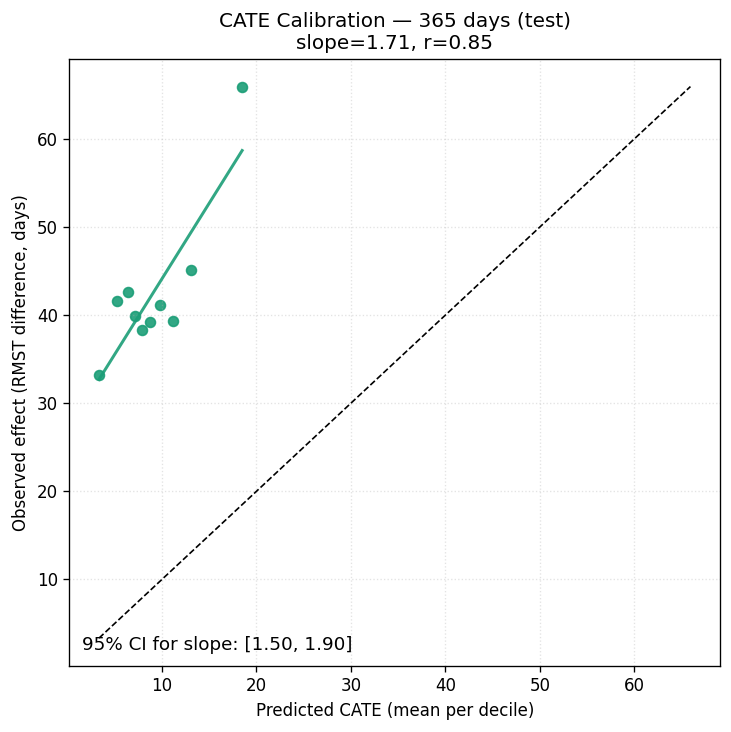

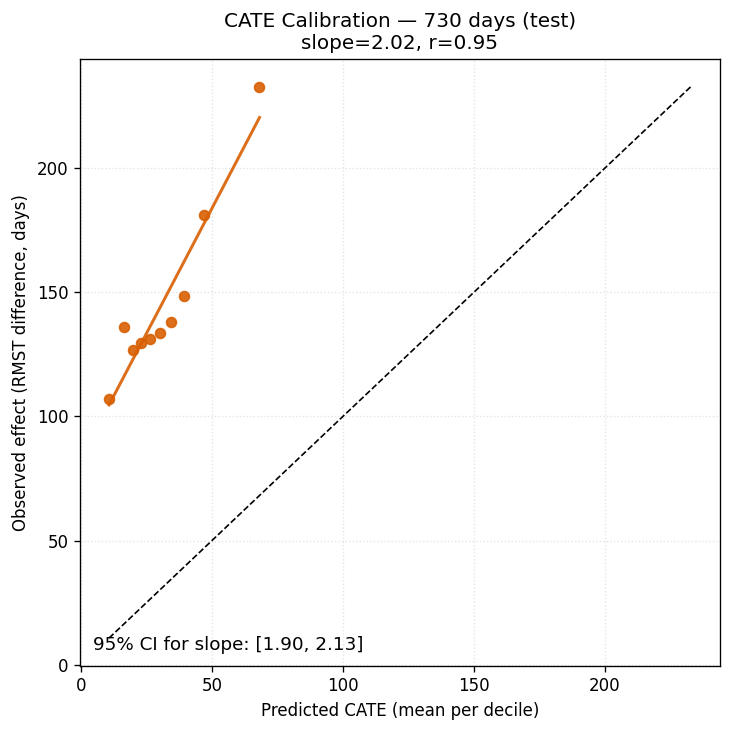

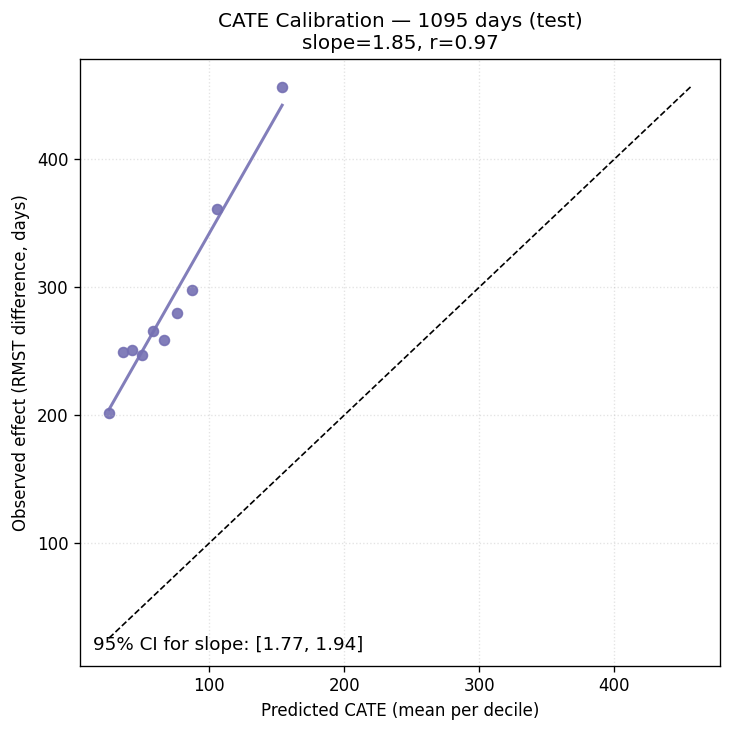

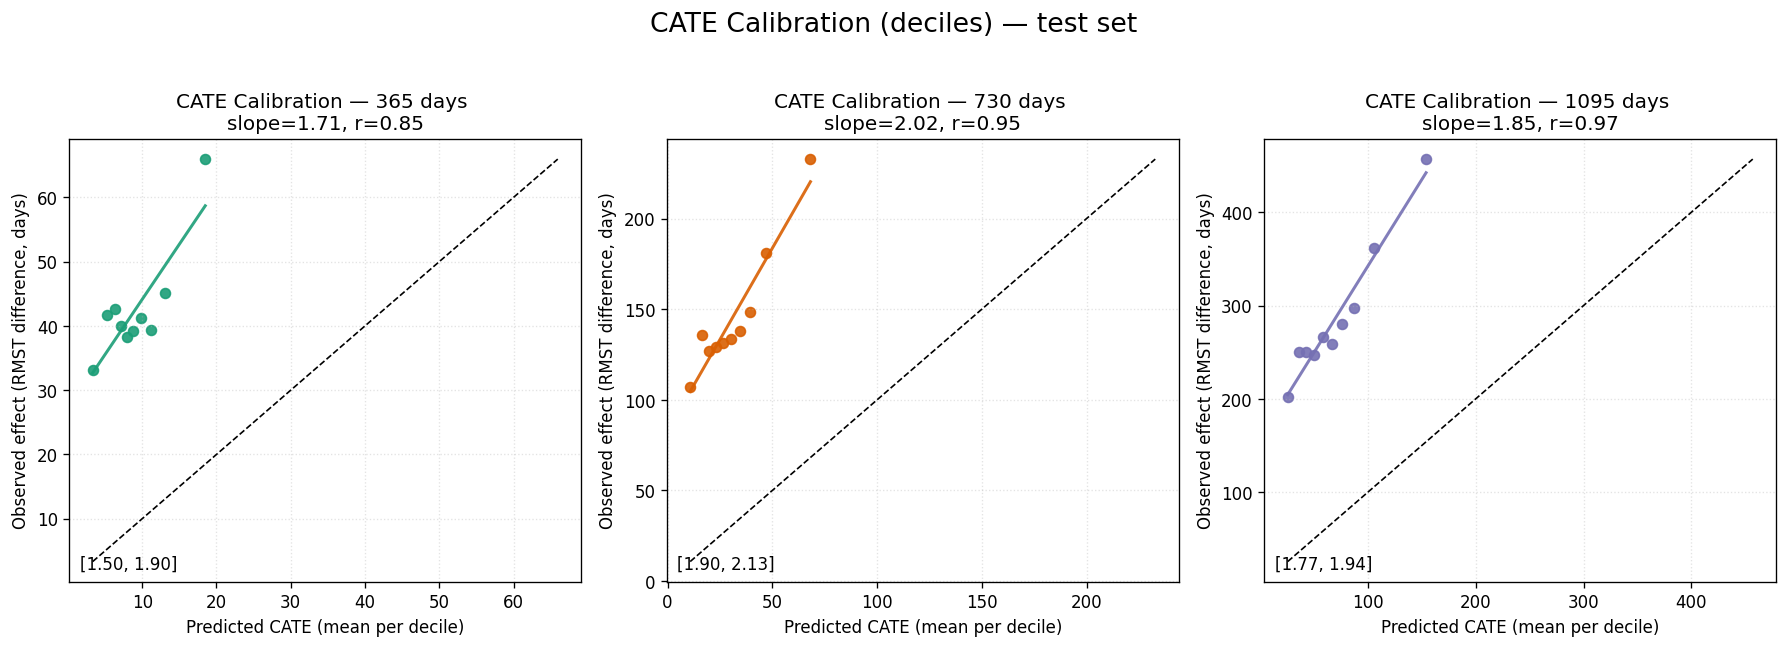

,Horizon (days),Slope,Slope 95% CI low,Slope 95% CI high,Pearson r
0,365,1.714995,1.504365,1.904303,0.850083
1,730,2.015113,1.902568,2.126721,0.950244
2,1095,1.853968,1.770002,1.942859,0.973932


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def _rmst(Y, H): return np.minimum(np.asarray(Y, float), H)

def _obs_effect_bin(R, T, ps, ipc, mask):
    Rb, Tb, psb, ipcb = R[mask], T[mask], ps[mask], ipc[mask]
    if Rb.size == 0: return np.nan
    psb = np.clip(psb, 1e-6, 1-1e-6)
    p_t = Tb.mean() if Tb.size else 0.5
    w_t = ipcb * p_t / psb
    w_c = ipcb * (1 - p_t) / (1 - psb)
    t = Tb == 1
    c = ~t
    mu_t = (w_t[t] * Rb[t]).sum() / (w_t[t].sum() + 1e-12) if t.any() else np.nan
    mu_c = (w_c[c] * Rb[c]).sum() / (w_c[c].sum() + 1e-12) if c.any() else np.nan
    return mu_t - mu_c

def build_calibration(df, tau_col, horizon_days, ipc_col, n_bins=10, trim=0.01):
    R   = _rmst(df["Y"].values, horizon_days)
    T   = df["T_365"].values.astype(int)
    ps  = np.clip(df["ps"].values.astype(float), trim, 1-trim)
    ipc = df[ipc_col].values.astype(float)
    tau = df[tau_col].values.astype(float)

    bins = pd.qcut(pd.Series(tau).rank(method="first"), n_bins, labels=False)
    rows = []
    for b in range(n_bins):
        m = (bins == b).values
        rows.append({
            "bin": b + 1,
            "pred_mean": tau[m].mean(),
            "obs_effect": _obs_effect_bin(R, T, ps, ipc, m),
            "n": int(m.sum())
        })
    B = pd.DataFrame(rows).dropna()
    x, y = B["pred_mean"].values, B["obs_effect"].values
    w = np.sqrt(np.maximum(B["n"].values, 1))
    slope, intercept = np.polyfit(x, y, 1, w=w)
    r, _ = pearsonr(x, y)
    return B, {"slope": slope, "intercept": intercept, "r": r}

def bootstrap_ci(df, tau_col, horizon_days, ipc_col, n_bins=10, trim=0.01, B=300, seed=2025):
    rng = np.random.default_rng(seed)
    n = len(df); slopes = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        bins_b, stats_b = build_calibration(df.iloc[idx], tau_col, horizon_days, ipc_col, n_bins, trim)
        slopes.append(stats_b["slope"])
    lo, hi = np.percentile(slopes, [2.5, 97.5])
    return float(lo), float(hi)

def plot_calibration(B, stats, H, ax=None, color="#1b9e77", title_suffix="(test)"):
    x, y = B["pred_mean"].values, B["obs_effect"].values
    if ax is None: fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.scatter(x, y, s=35, color=color, alpha=0.9)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    xx = np.linspace(x.min(), x.max(), 100)
    ax.plot(xx, stats["slope"]*xx + stats["intercept"], lw=1.8, color=color, alpha=0.9)
    ax.set_xlabel("Predicted CATE (mean per decile)")
    ax.set_ylabel("Observed effect (RMST difference, days)")
    ax.set_title(f"CATE Calibration — {H} days {title_suffix}\n"
                 f"slope={stats['slope']:.2f}, r={stats['r']:.2f}")
    ax.grid(linestyle=":", alpha=0.35)
    return ax

cfgs = [
    ("tau1", 365,  "ipc_weight_365",  "#1b9e77", "calibration_365"),
    ("tau2", 730,  "ipc_weight_730",  "#d95f02", "calibration_730"),
    ("tau3", 1095, "ipc_weight_1095", "#7570b3", "calibration_1095"),
]

calib_outputs = {}  
for tau_col, H, ipc_col, color, stem in cfgs:
    B, stats = build_calibration(test_merged, tau_col, H, ipc_col, n_bins=10, trim=0.01)
    lo, hi  = bootstrap_ci(test_merged, tau_col, H, ipc_col, n_bins=10, trim=0.01, B=300, seed=2025)
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    plot_calibration(B, stats, H, ax=ax, color=color, title_suffix="(test)")
    ax.text(0.02, 0.02, f"95% CI for slope: [{lo:.2f}, {hi:.2f}]", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=11)
    plt.tight_layout()
    fig.savefig(MAIN_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(MAIN_DIR / f"{stem}.png", dpi=600, bbox_inches="tight")
    plt.show()
    calib_outputs[H] = {"bins": B, "stats": stats, "ci": (lo, hi)}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=False, sharey=False)
for ax, (tau_col, H, ipc_col, color, stem) in zip(axes, cfgs):
    B  = calib_outputs[H]["bins"]
    st = calib_outputs[H]["stats"]
    lo, hi = calib_outputs[H]["ci"]
    plot_calibration(B, st, H, ax=ax, color=color, title_suffix="")
    ax.text(0.02, 0.02, f"[{lo:.2f}, {hi:.2f}]", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=10)
plt.tight_layout()
fig.savefig(MAIN_DIR / "calibration_three_panel.pdf", bbox_inches="tight")
fig.savefig(MAIN_DIR / "calibration_three_panel.png", dpi=600, bbox_inches="tight")
plt.show()


for H in calib_outputs:
    calib_outputs[H]["bins"].to_csv(MAIN_DIR / f"calibration_bins_{H}_days.csv", index=False)

summary_rows = []
for H in [365, 730, 1095]:
    st = calib_outputs[H]["stats"]; lo, hi = calib_outputs[H]["ci"]
    summary_rows.append({
        "Horizon (days)": H,
        "Slope": st["slope"], "Slope 95% CI low": lo, "Slope 95% CI high": hi,
        "Pearson r": st["r"]
    })
calibration_summary = pd.DataFrame(summary_rows)
display(calibration_summary)
calibration_summary.to_csv(MAIN_DIR / "calibration_summary_table.csv", index=False)
